# 🎯 Introduction to Optimization in Neural Network Training

This notebook follows **Vizuara's Lecture 9** from the *Neural Networks from Scratch* series. Explore why we need optimization, try two naive strategies (random selection vs random adjustment of weights and biases), and see why **calculus and gradients** are needed for robust training.

**📺 Source:** [Lecture 9 - Introduction to Optimization in Neural Network training](https://www.youtube.com/watch?v=WVFMxpTD09w) (Vizuara)

Introducing Optimization  
Strategy 1: Randomly select weights and biases  
Strategy 2: Randomly adjusting weights and biases  
Why we need calculus

---
## 1️⃣ Setup: data and network components

We use two datasets:
- **Vertical data** — three vertical strips (easy to separate); good to see strategies work or fail clearly.
- **Spiral data** — three winding classes (hard); Strategy 2 fails here, motivating gradient-based methods.

We use the same building blocks as in *Learning_neural_network_from_scratch.ipynb*: Dense layers, ReLU, Softmax, and categorical cross-entropy loss.

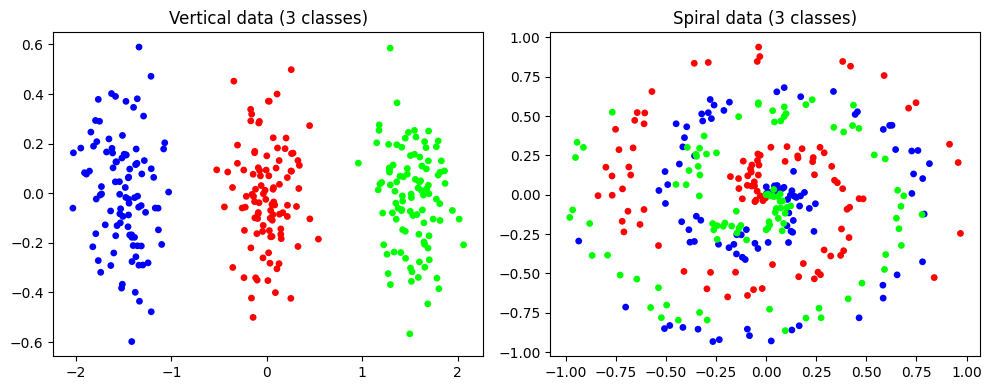

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def vertical_data(samples_per_class=100, classes=3):
    """Simple vertical strips: class k has x1 in a band, x2 random."""
    X = np.zeros((samples_per_class *  classes, 2))
    y = np.zeros(samples_per_class * classes, dtype=int)
    for c in range(classes):
        ix = range(samples_per_class * c, samples_per_class * (c + 1))
        X[ix, 0] = np.random.randn(samples_per_class) * 0.2 + (c - 1) * 1.5  # vertical bands
        X[ix, 1] = np.random.randn(samples_per_class) * 0.2
        y[ix] = c
    return X, y

def spiral_data_fallback(samples=100, classes=3):
    """Spiral-like data without nnfs."""
    np.random.seed(42)
    n = samples
    t = np.linspace(0, 4 * np.pi, n)
    X = np.zeros((n * classes, 2))
    y = np.zeros(n * classes, dtype=int)
    for c in range(classes):
        r = np.linspace(0.5, 2, n) + 0.2 * np.random.randn(n)
        X[c * n:(c + 1) * n, 0] = r * np.cos(t + c * 2 * np.pi / classes)
        X[c * n:(c + 1) * n, 1] = r * np.sin(t + c * 2 * np.pi / classes)
        y[c * n:(c + 1) * n] = c
    return X, y

# Vertical data for Strategy 1 and 2
X_v, y_v = vertical_data(100, 3)
# Spiral for Strategy 2 failure demo
try:
    import nnfs
    from nnfs.datasets import spiral_data
    nnfs.init()
    X_s, y_s = spiral_data(samples=100, classes=3)
except ImportError:
    X_s, y_s = spiral_data_fallback(100, 3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(X_v[:, 0], X_v[:, 1], c=y_v, cmap="brg", s=15)
ax1.set_title("Vertical data (3 classes)")
ax2.scatter(X_s[:, 0], X_s[:, 1], c=y_s, cmap="brg", s=15)
ax2.set_title("Spiral data (3 classes)")
plt.tight_layout()
plt.show()

In [2]:
# Network components (same as in Learning_neural_network_from_scratch.ipynb)
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases

class Activation_ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)

class Activation_Softmax:
    def forward(self, inputs):
        exp_vals = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        self.output = exp_vals / np.sum(exp_vals, axis=1, keepdims=True)

class Loss_CategoricalCrossentropy:
    def calculate(self, output, y_true):
        n_samples = len(output)
        y_pred_clipped = np.clip(output, 1e-7, 1 - 1e-7)
        correct = y_pred_clipped[range(n_samples), y_true]
        return np.mean(-np.log(correct))

def accuracy(y_pred_probs, y_true):
    return np.mean(np.argmax(y_pred_probs, axis=1) == y_true)

---
## 2️⃣ Strategy 1: Randomly select weights and biases

**Idea:** At each iteration, sample **completely new** weights and biases (e.g. from a small Gaussian). Run a forward pass, compute loss (and accuracy). Keep the parameters that give the **lowest loss so far**. Repeat many times (e.g. 10,000–100,000).

**Result on vertical data:** Loss barely decreases (e.g. ~1.99 → ~1.95), accuracy stays near **33%** (like random guessing). With 21 parameters, random search in high dimensions is ineffective.

In [3]:
# Strategy 1: fully random weights/biases, keep best
np.random.seed(42)
dense1 = Layer_Dense(2, 3)
relu = Activation_ReLU()
dense2 = Layer_Dense(3, 3)
softmax = Activation_Softmax()
loss_fn = Loss_CategoricalCrossentropy()

best_w1 = dense1.weights.copy()
best_b1 = dense1.biases.copy()
best_w2 = dense2.weights.copy()
best_b2 = dense2.biases.copy()
min_loss = float("inf")
n_iters = 10000
scale = 0.05

for i in range(n_iters):
    dense1.weights = scale * np.random.randn(2, 3)
    dense1.biases = scale * np.random.randn(1, 3)
    dense2.weights = scale * np.random.randn(3, 3)
    dense2.biases = scale * np.random.randn(1, 3)

    dense1.forward(X_v)
    relu.forward(dense1.output)
    dense2.forward(relu.output)
    softmax.forward(dense2.output)
    loss = loss_fn.calculate(softmax.output, y_v)

    if loss < min_loss:
        min_loss = loss
        best_w1, best_b1 = dense1.weights.copy(), dense1.biases.copy()
        best_w2, best_b2 = dense2.weights.copy(), dense2.biases.copy()
        if i % 1000 == 0 or i == n_iters - 1:
            acc = accuracy(softmax.output, y_v)
            print(f"iter {i:5d}  loss={loss:.4f}  acc={acc:.4f}")

dense1.weights, dense1.biases = best_w1, best_b1
dense2.weights, dense2.biases = best_w2, best_b2
dense1.forward(X_v)
relu.forward(dense1.output)
dense2.forward(relu.output)
softmax.forward(dense2.output)
print(f"\nStrategy 1 (vertical) — Best loss: {loss_fn.calculate(softmax.output, y_v):.4f}  Accuracy: {accuracy(softmax.output, y_v):.4f}")

iter     0  loss=1.0990  acc=0.3333

Strategy 1 (vertical) — Best loss: 1.0865  Accuracy: 0.6667


---
## 3️⃣ Strategy 2: Randomly *adjust* weights and biases

**Idea:** If the current loss is **lower** than the best so far, update the “best” parameters and set the **next** trial to “current best + small random perturbation.” If the loss **increases**, do **not** update best; next iteration, start again from the previous best (or equivalently: only add perturbations when we improved). So we are doing **local** random search instead of global.

**Result on vertical data:** Loss drops sharply (e.g. ~1.99 → ~0.16), accuracy reaches **~94%**. Strategy 2 works well on this simple dataset.

In [4]:
# Strategy 2: random adjustments; update only when loss decreases
np.random.seed(42)
dense1 = Layer_Dense(2, 3)
relu = Activation_ReLU()
dense2 = Layer_Dense(3, 3)
softmax = Activation_Softmax()
loss_fn = Loss_CategoricalCrossentropy()

best_w1 = dense1.weights.copy()
best_b1 = dense1.biases.copy()
best_w2 = dense2.weights.copy()
best_b2 = dense2.biases.copy()
min_loss = float("inf")
n_iters = 10000
scale = 0.05

for i in range(n_iters):
    # Current params = best + small random adjustment
    dense1.weights = best_w1 + scale * np.random.randn(2, 3)
    dense1.biases = best_b1 + scale * np.random.randn(1, 3)
    dense2.weights = best_w2 + scale * np.random.randn(3, 3)
    dense2.biases = best_b2 + scale * np.random.randn(1, 3)

    dense1.forward(X_v)
    relu.forward(dense1.output)
    dense2.forward(relu.output)
    softmax.forward(dense2.output)
    loss = loss_fn.calculate(softmax.output, y_v)

    if loss < min_loss:
        min_loss = loss
        best_w1, best_b1 = dense1.weights.copy(), dense1.biases.copy()
        best_w2, best_b2 = dense2.weights.copy(), dense2.biases.copy()
        if i % 1000 == 0 or i == n_iters - 1:
            print(f"iter {i:5d}  loss={loss:.4f}  acc={accuracy(softmax.output, y_v):.4f}")

dense1.weights, dense1.biases = best_w1, best_b1
dense2.weights, dense2.biases = best_w2, best_b2
dense1.forward(X_v)
relu.forward(dense1.output)
dense2.forward(relu.output)
softmax.forward(dense2.output)
print(f"\nStrategy 2 (vertical) — Best loss: {loss_fn.calculate(softmax.output, y_v):.4f}  Accuracy: {accuracy(softmax.output, y_v):.4f}")

iter     0  loss=1.0988  acc=0.3333
iter  1000  loss=0.0000  acc=1.0000

Strategy 2 (vertical) — Best loss: 0.0000  Accuracy: 1.0000


---
## 4️⃣ Strategy 2 on spiral data: it fails

Running the **same** Strategy 2 on the **spiral** dataset: loss barely decreases (e.g. ~1.1 → ~1.04), accuracy stays low (~40%). So “randomly adjust and keep improvements” is **not robust** — it works for simple (e.g. vertical) data but not for complex, non-linearly separable data. We need a better way to choose the **direction and size** of updates → **gradients**.

In [5]:
# Strategy 2 on spiral data
np.random.seed(42)
dense1 = Layer_Dense(2, 3)
relu = Activation_ReLU()
dense2 = Layer_Dense(3, 3)
softmax = Activation_Softmax()
loss_fn = Loss_CategoricalCrossentropy()

best_w1 = dense1.weights.copy()
best_b1 = dense1.biases.copy()
best_w2 = dense2.weights.copy()
best_b2 = dense2.biases.copy()
min_loss = float("inf")
n_iters = 10000
scale = 0.05

for i in range(n_iters):
    dense1.weights = best_w1 + scale * np.random.randn(2, 3)
    dense1.biases = best_b1 + scale * np.random.randn(1, 3)
    dense2.weights = best_w2 + scale * np.random.randn(3, 3)
    dense2.biases = best_b2 + scale * np.random.randn(1, 3)

    dense1.forward(X_s)
    relu.forward(dense1.output)
    dense2.forward(relu.output)
    softmax.forward(dense2.output)
    loss = loss_fn.calculate(softmax.output, y_s)

    if loss < min_loss:
        min_loss = loss
        best_w1, best_b1 = dense1.weights.copy(), dense1.biases.copy()
        best_w2, best_b2 = dense2.weights.copy(), dense2.biases.copy()
        if i % 2000 == 0 or i == n_iters - 1:
            print(f"iter {i:5d}  loss={loss:.4f}  acc={accuracy(softmax.output, y_s):.4f}")

dense1.weights, dense1.biases = best_w1, best_b1
dense2.weights, dense2.biases = best_w2, best_b2
dense1.forward(X_s)
relu.forward(dense1.output)
dense2.forward(relu.output)
softmax.forward(dense2.output)
print(f"\nStrategy 2 (spiral) — Best loss: {loss_fn.calculate(softmax.output, y_s):.4f}  Accuracy: {accuracy(softmax.output, y_s):.4f}")

iter     0  loss=1.0997  acc=0.3333

Strategy 2 (spiral) — Best loss: 1.0480  Accuracy: 0.4100


---
## 5️⃣ Why we need calculus

Strategy 2 improves on Strategy 1 by using **local** updates (stay near good parameters), but the **step direction and size** are still random. To minimize the loss efficiently we should:

1. Know **which direction** decreases the loss fastest → the **negative gradient** (direction of steepest descent).
2. Know **how much** to move → **learning rate × gradient** (and variants like SGD, Adam).

That requires **derivatives** of the loss with respect to each weight and bias. So we need:

- **Derivatives** and **partial derivatives** of the loss w.r.t. parameters  
- **Gradient** (vector of partial derivatives)  
- **Chain rule** to backpropagate through layers  

Once we have gradients, we can update weights with **gradient descent**:  
\(W \leftarrow W - \text{lr} \cdot \frac{\partial L}{\partial W}\).

**📺 Next in the series:** The video mentions a follow-up lecture on derivatives, partial derivatives, gradient, and chain rule, then backpropagation. See [Vizuara](https://www.youtube.com/watch?v=WVFMxpTD09w) for the full playlist.

---
## 📌 Summary

| Strategy | Vertical data | Spiral data |
|----------|----------------|-------------|
| **1: Random select** | Poor (loss ~1.95, acc ~33%) | — |
| **2: Random adjust** | Good (loss ~0.16, acc ~94%) | Poor (loss ~1.04, acc ~40%) |

**Takeaway:** Naive random search is insufficient; we need **gradient-based optimization** (and hence calculus: derivatives, gradient, chain rule, backprop) to train neural networks reliably on complex data.